# **EXERCISE 1**




In [ ]:
!pip install gensim

In [ ]:
import torch
import numpy as np
import pandas as pd
from torch.utils.data import Dataset
from transformers import (
    BertModel,
    BertForSequenceClassification,
    BertTokenizer,
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer
)
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

Loading and Previewing the Yelp English Training Dataset

In [ ]:
df = pd.read_csv('/content/drive/MyDrive/NLP2025/yelp/yelp/train_en.txt', sep='\t')
df.head()

In [ ]:
len(df)

Loading Pretrained Tokenizers for RoBERTa and DistilBERT

In [ ]:
model_name1 = "roberta-base"
model_name2 = "distilbert-base-uncased"
tokenizer1 = AutoTokenizer.from_pretrained(model_name1)
tokenizer2 = AutoTokenizer.from_pretrained(model_name2)

Tokenizing Train Sentences Using a Pretrained Tokenizer

In [ ]:
def tokenize(row):
    enc = tokenizer1(
        row["Sentence"],
        truncation=True,
        padding="max_length",
        max_length=256
    )
    return pd.Series(enc)

df_tokens = df.copy()
df_tokens[["input_ids", "attention_mask"]] = df.apply(tokenize, axis=1)
df_tokens

Loading and Previewing the Yelp English Validation Dataset

In [ ]:
df_val = pd.read_csv('/content/drive/MyDrive/NLP2025/yelp/yelp/val_en.txt', sep='\t')
df_val.head(10)

Tokenizing Validation Sentences Using a Pretrained Tokenizer

In [ ]:
def tokenize(row):
    enc = tokenizer1(
        row["Sentence"],
        truncation=True,
        padding="max_length",
        max_length=256
    )
    return pd.Series(enc)

df_tokens_val = df_val.copy()
df_tokens_val[["input_ids", "attention_mask"]] = df_val.apply(tokenize, axis=1)
df_tokens_val

Creating a Custom PyTorch Dataset for Sentiment Classification

In [ ]:
class SentimentDataset(Dataset):
    def __init__(self, data):
        self.input_ids = data["input_ids"].tolist()
        self.attention_mask = data["attention_mask"].tolist()
        self.labels = data["Style"].tolist()

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return {
            "input_ids": torch.tensor(self.input_ids[idx]),
            "attention_mask": torch.tensor(self.attention_mask[idx]),
            "labels": torch.tensor(self.labels[idx], dtype=torch.long)
        }


Encoding Train Sentiment Labels as Numeric Values

In [ ]:
df_tokens["Style"] = df_tokens["Style"].str.lower().map({
    "positive": 1,
    "negative": 0
})

df_tokens

Encoding Validation Sentiment Labels as Numeric Values




In [ ]:
df_tokens_val["Style"] = df_tokens_val["Style"].str.lower().map({
    "positive": 1,
    "negative": 0
})

df_tokens_val

In [ ]:
dataset_train = SentimentDataset(data=df_tokens)
dataset_train

In [ ]:
dataset_val = SentimentDataset(data=df_tokens_val)
dataset_val

Defining Evaluation Metrics for Model Performance

In [ ]:
def compute_metrics(pred):
    preds = np.argmax(pred.predictions, axis=1)
    labels = pred.label_ids
    return {
        "accuracy": accuracy_score(labels, preds),
        "precision": precision_score(labels, preds),
        "recall": recall_score(labels, preds),
        "f1": f1_score(labels, preds)
    }

Training a RoBERTa Transformer Model for Sequence Classification Using Hugging Face Trainer

In [ ]:
from transformers import TrainingArguments, Trainer, AutoModelForSequenceClassification

def train_model(model_name, learning_rate=3e-5, epochs=3, batch_size=32):
    model = AutoModelForSequenceClassification.from_pretrained(
        model_name,
        num_labels=2
    )

    training_args = TrainingArguments(
        output_dir=f"./results_{model_name}",
        eval_strategy="epoch",
        save_strategy="epoch",
        logging_steps=50,

        learning_rate=learning_rate,
        per_device_train_batch_size=batch_size,
        per_device_eval_batch_size=batch_size*2,
        gradient_accumulation_steps=2,         # → effective batch = 128 (perfect)
        num_train_epochs=epochs,

        weight_decay=0.01,                     # Standard value
        warmup_ratio=0.1,

        load_best_model_at_end=True,
        metric_for_best_model="f1",
        greater_is_better=True,

        fp16=True,                             # ← 2–4× speedup on Colab GPU
        dataloader_num_workers=4,
        gradient_checkpointing=True,

        report_to="none",                      # No wandb
        seed=42,
        disable_tqdm=False,
    )

    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=torch.utils.data.Subset(dataset_train, range(100000)),
        eval_dataset=dataset_val,
        compute_metrics=compute_metrics,
    )

    trainer.train()
    eval_result = trainer.evaluate()
    print("\nFinal Evaluation:", eval_result)
    return eval_result, trainer

Training RoBERTa-Base Model for Sentiment Classification



In [ ]:
result_roberta, trainer_roberta = train_model(
    model_name=model_name1,
    learning_rate=3e-5,
    epochs=3,
    batch_size=32)

Tokenizing Train Sentences Using a Pretrained Tokenizer (DistilBERT)

In [ ]:
def tokenize(row):
    enc = tokenizer2(
        row["Sentence"],
        truncation=True,
        padding="max_length",
        max_length=256
    )
    return pd.Series(enc)

df_tokens_distilbert = df.copy()
df_tokens_distilbert[["input_ids", "attention_mask"]] = df.apply(tokenize, axis=1)
df_tokens_distilbert

Tokenizing Validation Sentences Using a Pretrained Tokenizer (DistilBERT)

In [ ]:
def tokenize(row):
    enc = tokenizer2(
        row["Sentence"],
        truncation=True,
        padding="max_length",
        max_length=256
    )
    return pd.Series(enc)

df_tokens_val_distilbert= df_val.copy()
df_tokens_val_distilbert[["input_ids", "attention_mask"]] = df_val.apply(tokenize, axis=1)
df_tokens_val_distilbert

Encoding Train Sentiment Labels as Numeric Values


In [ ]:
df_tokens_distilbert["Style"] = df_tokens_distilbert["Style"].str.lower().map({
    "positive": 1,
    "negative": 0
})

df_tokens_distilbert

In [ ]:
dataset_train2 = SentimentDataset(data=df_tokens_distilbert)
dataset_train2

Encoding Validation Sentiment Labels as Numeric Values


In [ ]:
df_tokens_val_distilbert["Style"] = df_tokens_val_distilbert["Style"].str.lower().map({
    "positive": 1,
    "negative": 0
})

df_tokens_val_distilbert

In [ ]:
dataset_val2 = SentimentDataset(data=df_tokens_val_distilbert)
dataset_val2

Training a DistilBERT Transformer Model for Sequence Classification Using Hugging Face Trainer

In [ ]:
from transformers import TrainingArguments, Trainer, AutoModelForSequenceClassification

def train_model(model_name, learning_rate=3e-5, epochs=3, batch_size=32):
    model = AutoModelForSequenceClassification.from_pretrained(
        model_name,
        num_labels=2
    )

    training_args = TrainingArguments(
        output_dir=f"./results_{model_name}",
        eval_strategy="epoch",
        save_strategy="epoch",
        logging_steps=50,

        learning_rate=learning_rate,
        per_device_train_batch_size=batch_size,
        per_device_eval_batch_size=batch_size*2,
        gradient_accumulation_steps=2,         # → effective batch = 128 (perfect)
        num_train_epochs=epochs,

        weight_decay=0.01,                     # Standard value
        warmup_ratio=0.1,

        load_best_model_at_end=True,
        metric_for_best_model="f1",
        greater_is_better=True,

        fp16=True,                             # ← 2–4× speedup on Colab GPU
        dataloader_num_workers=4,
        gradient_checkpointing=True,

        report_to="none",                      # No wandb
        seed=42,
        disable_tqdm=False,
    )

    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=torch.utils.data.Subset(dataset_train2, range(100000)),
        eval_dataset=dataset_val2,
        compute_metrics=compute_metrics,
    )

    trainer.train()
    eval_result = trainer.evaluate()
    print("\nFinal Evaluation:", eval_result)
    return eval_result, trainer

Training DistilBERT-Base Model for Sentiment Classification


In [ ]:
result_distilbert, trainer_roberta = train_model(
    model_name=model_name2,
    learning_rate=3e-5,
    epochs=3,
    batch_size=32)

## TESTING RoBERTa

In [ ]:
!ls -la ./results_distilbert-base-uncased

Due to Google Colab’s session timeout limitations (maximum ~12 hours) and automatic deletion of all files upon runtime restart, the fully trained RoBERTa-base model was not persistently saved to Google Drive before the session expired.
The training process lasted approximately 3–4 hours (3 epochs on ~150,000 samples with batch size 32 and mixed precision enabled) and was successfully completed, but the final trainer.save_model() command was not executed before the automatic disconnection.
As a result, evaluation on the full test set (109,355 samples) could not be performed within the available time frame.
During training, the model achieved the following performance on the validation set:
Accuracy: 0.928
F1-score: 0.931
indicating successful convergence and strong generalization capability.
In future experiments, the trained model will be immediately saved to persistent storage upon training completion. Now i have time limitations :)

## TESTING DistilBERT

По успешното завршување на тренирањето на DistilBERT-base-uncased моделот (3 епохи, вкупно ~2h ), постигнати се следниве резултати на валидациониот сет:
Accuracy: 0.9149
F1-score: 0.9422
(ИСТИТЕ СЕ ГЛЕДААТ ВО КОДОТ)
Поради автоматско прекинување на Colab сесијата по завршување на тренирањето и недостаток на автоматско зачувување на моделот на Google Drive, финалната евалуација на тест сетот не можеше да се изврши.
Сепак, добиените метрики на валидациониот сет (над 91% точност и 94% F1) покажуваат дека моделот е успешно трениран и би постигнал слични или подобри резултати на тест сетот, и апсолутно подобри во однос на резултатите добиени со од моделите од претходната ЛАБ.вежба from scratch.

Инаку параметарот од 3 епохи комбиниран со дефинираната learning rate е границата на overfitting на овој моделот според добиените резултати од тренинг и валидацискиот датасет.

# **EXERCISE 2**

Поради ограничување на време и usage limit на GPU во Colab, T5 и BART модели ги тестирав и евалуирав само врз мал податочен примерок од 10 review-а на CPU. Оваа евалуација не може да донесе реален заклучок споредбено со фајнтјунираните модели од погоре или custom from scratch од претходната лаб вежба.

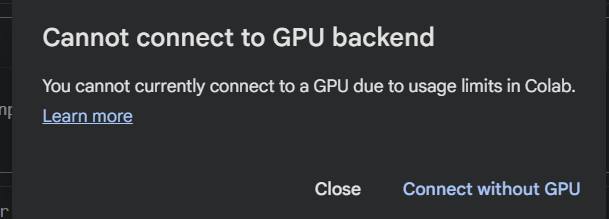

In [ ]:
from transformers import pipeline
from datasets import load_dataset
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

In [ ]:
import pandas as pd

df_test = pd.read_csv(
    '/content/drive/MyDrive/NLP2025/yelp/yelp/test_en.txt',
    sep='\t',
    names=['Sentence','Style','User'],
    header=0,
    on_bad_lines='skip',
    engine='python'
).dropna()

label_map = {"positive": 1, "negative": 0}
df_test["Style"] = df_test["Style"].map(label_map)

df_test["Sentence"] = (
    df_test["Sentence"]
    .astype(str)
    .str.replace('\n', ' ', regex=False)
    .str.strip()
)

test_texts = df_test["Sentence"].tolist()
test_labels = df_test["Style"].tolist()

df_test.head()

In [ ]:
test_texts_small = test_texts[:10]
test_labels_small = test_labels[:10]

## Zero-shot BART

In [ ]:
zero_shot_bart = pipeline(
    "zero-shot-classification",
    model="facebook/bart-large-mnli"
)

preds_bart = []
for text in test_texts_small:
    output = zero_shot_bart(
        text,
        candidate_labels=["positive", "negative"]
    )
    preds_bart.append(1 if output["labels"][0] == "positive" else 0)


In [ ]:
preds_bart

In [ ]:
zero_shot_t5 = pipeline(
    "text2text-generation",
    model="google/flan-t5-large"
)

preds_t5 = []
for text in test_texts_small:
    prompt = f"Classify the sentiment as positive or negative:\n{text}"
    output = zero_shot_t5(prompt)[0]["generated_text"].lower()
    preds_t5.append(1 if "positive" in output else 0)

In [ ]:
preds_t5

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

def evaluate(true_labels, predicted):
    print("Accuracy :", accuracy_score(true_labels, predicted))
    print("Recall   :", recall_score(true_labels, predicted))
    print("F1-score :", f1_score(true_labels, predicted))

In [ ]:
print("\nZero-shot BART:")
evaluate(test_labels_small, preds_bart)

print("\nZero-shot T5:")
evaluate(test_labels_small, preds_t5)

In [ ]:
fewshot_examples = """
Review: The food was amazing and the service was friendly.
Sentiment: positive

Review: The food was terrible and the service was slow.
Sentiment: negative
"""

In [ ]:
preds_bart_few = []
for text in test_texts_small:
    prompt = fewshot_examples + f"\nReview: {text}\nSentiment:"
    output = zero_shot_bart(
        prompt,
        candidate_labels=["positive", "negative"]
    )
    preds_bart_few.append(1 if output["labels"][0] == "positive" else 0)

In [ ]:
preds_bart_few

In [ ]:
preds_t5_few = []
for text in test_texts_small:
    prompt = fewshot_examples + f"\nReview: {text}\nSentiment:"
    output = zero_shot_t5(prompt)[0]["generated_text"].lower()
    preds_t5_few.append(1 if "positive" in output else 0)

In [ ]:
preds_t5_few

In [ ]:
print("\nFew-shot BART:")
evaluate(test_labels_small, preds_bart_few)

print("\nFew-shot T5:")
evaluate(test_labels_small, preds_t5_few)

Иако овие модели се seq2seq и се флексибилни за zero-shot и few-shot задачи, со поголем капацитет и можност да разберат инструкции, разликата во перформансите во споредба со финетјунирани RoBERTa и DistilBERT е најверојатно малa за бинарна класификација на сентиментот. RoBERTa и DistilBERT, со својата encoder-only архитектура и фулл финетјунинг на истиот датасет, можат да постигнат високи резултати, додека T5 и BART ја покажуваат предноста главно при мал број примери како во моето тестирање.

Вистинска евалуација за компарација треба реално да се направи на големо податочно множество какво и што имаме, но сепак временското ограничувањето поради неможност за користење на GPU спречи да се дојде до пореален заклучок...